In [1]:
from datetime import datetime
import re
import json
import glob
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def filter_json_files_by_date(all_json_files: list[str], str_start_date: str, str_end_date: str) -> list[str]:
    start_date = datetime.strptime(str_start_date, '%Y%m%d')
    end_date = datetime.strptime(str_end_date, '%Y%m%d')

    def is_within_range(file):
        json_dates = re.findall(r'\d{8}', file)
        start_date_json = datetime.strptime(json_dates[0], '%Y%m%d')
        end_date_json = datetime.strptime(json_dates[1], '%Y%m%d')
        return (start_date_json >= start_date) & (start_date_json <= end_date) & (end_date_json >= start_date)

    return list(filter(is_within_range, all_json_files))

In [3]:
def extract_data_from_json(json_data, data_type: str) -> np.array:
    # Handle possible different data structures
    if data_type in json_data:
        data = np.array(json_data[data_type]["data"])
    elif "variables" in json_data and data_type in json_data["variables"]:
        data = np.array(json_data["variables"][data_type]["data"])
    else:
        raise KeyError(f"Data type '{data_type}' not found in JSON.")

    return data

In [4]:
def select_first_24h(parsed_times: np.array(datetime), data: np.array):
    start_time = parsed_times[0]  # Assuming times are sorted
    end_time = start_time + pd.Timedelta(hours=24)
    valid_indices = (parsed_times >= start_time) & (parsed_times < end_time)

    parsed_times = parsed_times[valid_indices]  # Filter timestamps
    data = data[valid_indices]  # Filter data

    return parsed_times, data

In [5]:
lake_name = "geneva"
data_type = 'U'
str_start_date = '20260126'
str_end_date = '20260128'

folder_json_path = fr"C:\Users\leroquan\Documents\Data\meteo\ICON reanalysis\raw_from_alplakes_api\{lake_name}"

In [13]:
def parse_weather_data(folder_json_path, data_type, str_start_date, str_end_date):
    all_json_files = glob.glob(os.path.join(folder_json_path, f'*_{data_type}.json'))
    json_files = filter_json_files_by_date(all_json_files, str_start_date, str_end_date)

    filtered_parsed_times=[]
    filtered_data = []
    for idx_file in range(len(json_files)):
        json_path = json_files[idx_file]
        json_data = json.load(open(json_path))
        data = extract_data_from_json(json_data, data_type)
        parsed_times = pd.to_datetime(
            np.array(json_data).item().get('time')
            ).tz_localize(None)
        temp_filtered_parsed_times, temp_filtered_data = select_first_24h(parsed_times, data)
        filtered_parsed_times.append(temp_filtered_parsed_times)
        filtered_data.append(temp_filtered_data)

    return np.concat(filtered_parsed_times), np.concat(filtered_data)

In [14]:
parsed_time_u, parsed_u = parse_weather_data(folder_json_path, 'U', str_start_date, str_end_date)
parsed_time_v, parsed_v = parse_weather_data(folder_json_path, 'V', str_start_date, str_end_date)

In [15]:
wind_speed = np.sqrt(parsed_v**2 + parsed_u**2)

In [24]:
xgrid, ygrid = np.meshgrid(range(parsed_u[0].shape[1]), range(parsed_u[0].shape[0]))

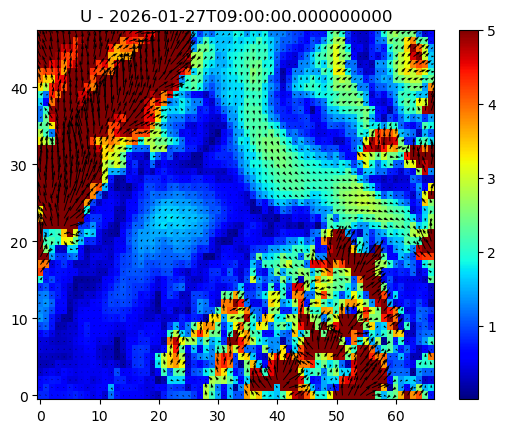

In [129]:
idx += 1
plt.quiver(xgrid, ygrid, parsed_u[idx], parsed_v[idx], scale=200)
plt.imshow(wind_speed[idx], origin='lower', aspect='auto', cmap='jet', vmax=5)
plt.title(f'{data_type} - {parsed_time_u[idx]}')
plt.colorbar()